In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # get FITS 
import pandas as pd             # get pandas 
import scipy.signal as sps
import scipy.ndimage.filters as snf
import matplotlib.pyplot as plt
import disk as d
import gaussian as g

## Bad Pixels and Cosmic Rays: 
- Handle bad data (hot pixels, dead pixels, cosmic rays) by making and multiplying masks (3M method)
- A mask is a Boolean array with same size as image
    - In languages without a Boolean type, use smallest integer (e.g., byte)
    - True=1=good, False=0=bad

    - If possible, ignore masked data
    - Else, "fix" bad pixels by interpolation (and tell people about it!)

- Make one mask for each input frame (flat, sky, object, dark)
- Median combinations count as 1
    - Ignore median combinations if same effects in different frame
    - AND/or multiply masks to get final mask

- Of course, always try to put your object on a part of the array away from bad pixels!
- Isolated pixels can use bilinear interpolation (remember astropy!)
- Regions of bad pixels: fit model to surrounding good data



## Making Masks: 
- Ideal: calculate (Data)-(Truth), flag anything not 0
  - Instead of "truth", use smoothed version of data (what eye does)
  - Must account for noise and real data
  - Subtract this image from the real one, set rejection levels
      - Set levels by standard deviations from median, and flag (sigma clipping)
  - Set levels by inspection (usually better, done once per itime-filter combo)
  
- If making mask from something flat, use larger box and tighter limits
    - Else, use small box and loose limits
    
- For mask from flat field, anything $0.5 \lt z \lt 1.5$ probably good

- Look at your masks, blink with data!

- If automating analysis (many images), test masks on many images!

- Start by making the "truth":

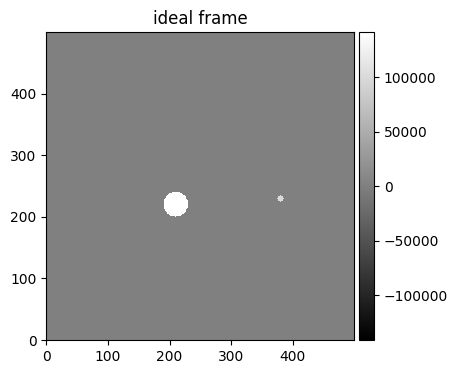

In [2]:
# make some fake data with a star, planet, and bad pixel

# size of image
ny = 500
nx = 500

# star properties
sy       = 220
sx       = 210
starflux = 1e7 # somewhat noisy, peak comparable to sky
starrad  = 20.

# planet properties
py         = 229
px         = 380
planetrad  = 5.
planetflux = 1e5

# sky property (only one)
skyflux = 1e2

# make the ideal image, add star and planet
im          = np.zeros((ny, nx))
im         += starflux   * d.disk(starrad, (sy, sx), (ny, nx))
im         += planetflux * d.disk(planetrad, (py, px), (ny, nx))


#show it.
quickmn = np.median(im)
quicksg = np.std(im)
nsl = -0.2
nsu = 0.2

plt.figure( figsize = ( 6,4 ) ) # figure 1
im1 = plt.imshow(im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im1,fraction=0.045, pad=0.01)

dm= plt.title("ideal frame")



In [3]:
# add atmospheric "seeing"
# convolution kernel
seewidth = 3.
gc       = int(5 * seewidth)
gw       = 2 * gc + 1
gcoo     = np.indices((gw, gw))
seekern  = g.gaussian(gcoo, (seewidth, seewidth), (gc, gc))



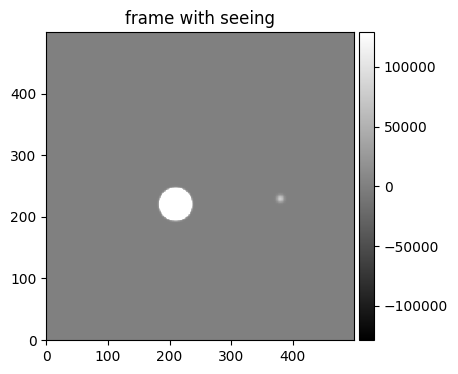

In [4]:
im = sps.convolve2d(im, seekern, mode='same')

#show it.
quickmn = np.median(im)
quicksg = np.std(im)


plt.figure( figsize = ( 6,4 ) ) # figure 1
im2 = plt.imshow(im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im2,fraction=0.045, pad=0.01)

dm= plt.title("frame with seeing")


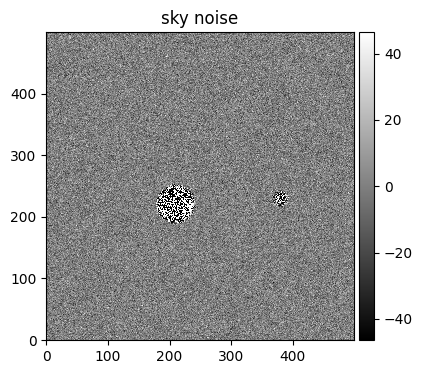

In [5]:
# add sky flux
im += skyflux

# add noise
noiseim = np.sqrt(im) * np.random.normal(size=(ny, nx)) #* 10


#show the noise first:
quickmn = np.median(noiseim)
quicksg = np.std(noiseim)


plt.figure( figsize = ( 6,4 ) ) # figure 1
im3 = plt.imshow(noiseim, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im3,fraction=0.045, pad=0.01)

dm= plt.title("sky noise")


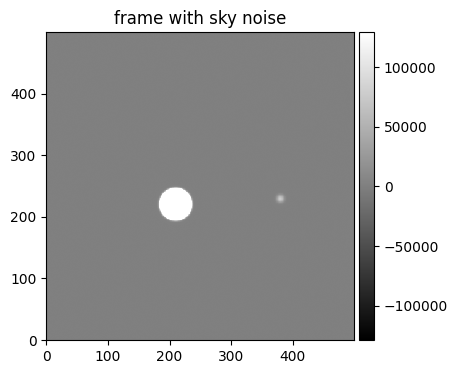

In [6]:
#show the noisy frame:
im     += noiseim

quickmn = np.median(im)
quicksg = np.std(im)


plt.figure( figsize = ( 6,4 ) ) # figure 1
im4 = plt.imshow(im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im4,fraction=0.045, pad=0.01)

dm= plt.title("frame with sky noise")


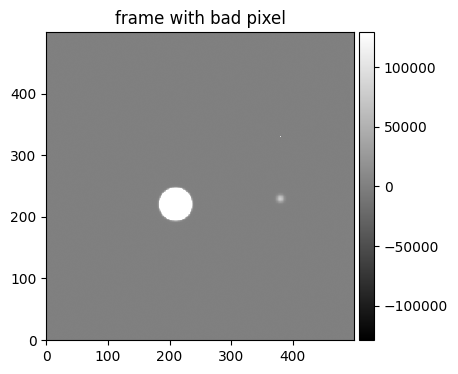

In [7]:
# add a bad pixel
by         = 330
bx         = 380
badflux    = 1e5
im[by, bx] = badflux


quickmn = np.median(im)
quicksg = np.std(im)


plt.figure( figsize = ( 6,4 ) ) # figure 1
im5 = plt.imshow(im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im5,fraction=0.045, pad=0.01)

dm= plt.title("frame with bad pixel")

## Ways to Make a Mask: 
  - By hand (e.g., for array defects)
  - Flag pixels above/below levels that are outside good data range (e.g., in flats)
  
  <br>
  - Calculate median-filtered image:    
    - Each pixel replaced by the median in a box around it
    - Size of box should be odd (centered on pixel)
    - May need to embed data in larger array or set flags in Python routine
    - [scipy.ndimage.filters.median_filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.median_filter.html) in Python
        - This method is good for smoothly-varying sources (e.g., galaxies), may not work for spiky things like stars.

C:\Users\Alex\AppData\Local\Temp\ipykernel_20076\3273558123.py:2: DeprecationWarning: Please import `median_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  med_im = snf.median_filter(im, size=3)


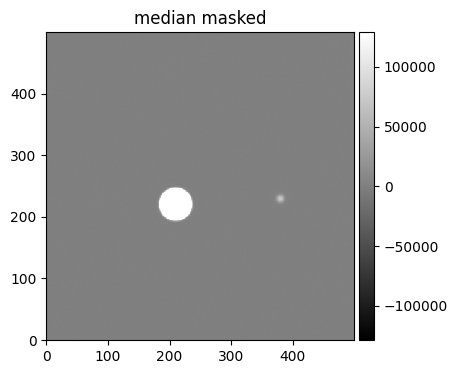

In [8]:
# median filter
med_im = snf.median_filter(im, size=3)

quickmn = np.median(med_im)
quicksg = np.std(med_im)

plt.figure( figsize = ( 6,4 ) ) # figure 1
im6 = plt.imshow(med_im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im6,fraction=0.045, pad=0.01)

dm= plt.title("median masked")

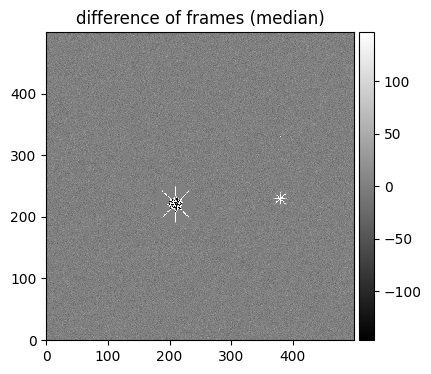

In [9]:
#plot difference of image with masked image:
dif_im = im - med_im

quickmn = np.median(dif_im)
quicksg = np.std(dif_im)

plt.figure( figsize = ( 6,4 ) ) # figure 1
im7 = plt.imshow(dif_im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im7,fraction=0.045, pad=0.01)

dm= plt.title("difference of frames (median)")

  - Calculate boxcar-filtered image:
    - Each pixel replaced by the average in a box around it
    - Size of box should be odd (centered on pixel)
    - [scipy.ndimage.filters.uniform_filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.uniform_filter.html) in Python
    - Sometimes better for stars, depends on seeing.

C:\Users\Alex\AppData\Local\Temp\ipykernel_20076\1786745453.py:2: DeprecationWarning: Please import `uniform_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  box_im = snf.uniform_filter(im, size=3)


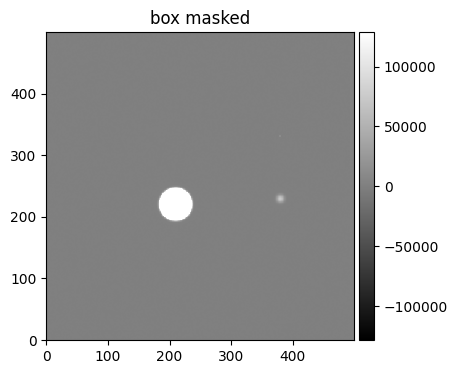

In [10]:
# boxcar filter
box_im = snf.uniform_filter(im, size=3)

quickmn = np.median(box_im)
quicksg = np.std(box_im)

plt.figure( figsize = ( 6,4 ) ) # figure 1
im8 = plt.imshow(box_im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im8,fraction=0.045, pad=0.01)

dm= plt.title("box masked")

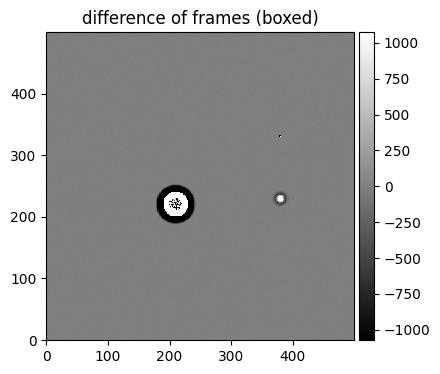

In [11]:
#plot difference of image with masked image:
dif_im = im - box_im

quickmn = np.median(dif_im)
quicksg = np.std(dif_im)

plt.figure( figsize = ( 6,4 ) ) # figure 1
im9 = plt.imshow(dif_im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im9,fraction=0.045, pad=0.01)

dm= plt.title("difference of frames (boxed)")

  - Calculate Gaussian-smoothed image:
    - Convolve image with Gaussian to smooth each pixel into neighbors
    - Width of Gaussian should not be more than a few pixels
    - [scipy.ndimage.filters.gaussian_filter](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.gaussian_filter.html) in Python
    - Sometimes better for stars, depends on seeing.

C:\Users\Alex\AppData\Local\Temp\ipykernel_20076\524118556.py:2: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  gau_im = snf.gaussian_filter(im, 3)


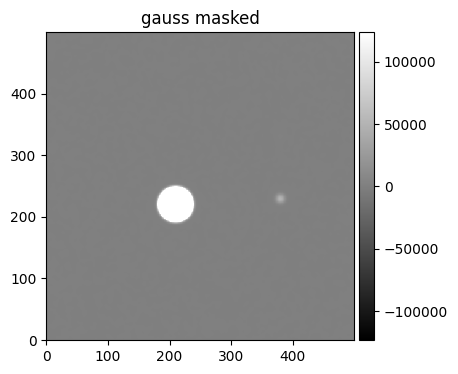

In [12]:
# Gaussian filter
gau_im = snf.gaussian_filter(im, 3)

quickmn = np.median(gau_im)
quicksg = np.std(gau_im)

plt.figure( figsize = ( 6,4 ) ) # figure 1
im10 = plt.imshow(gau_im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im10,fraction=0.045, pad=0.01)

dm= plt.title("gauss masked")

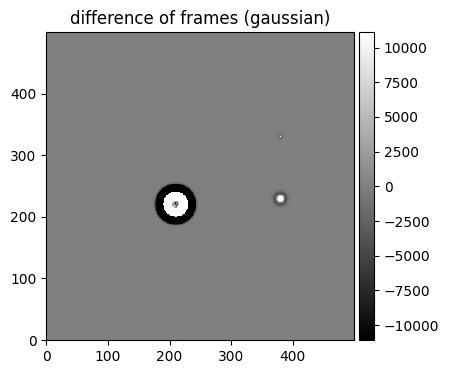

In [13]:
#plot difference of image with masked image:
dif_im = im - gau_im

quickmn = np.median(dif_im)
quicksg = np.std(dif_im)

plt.figure( figsize = ( 6,4 ) ) # figure 1
im11 = plt.imshow(dif_im, interpolation='none', origin='lower', 
           vmin=quickmn+nsl*quicksg, vmax=quickmn+nsu*quicksg, 
           cmap='gray')
plt. colorbar(im11,fraction=0.045, pad=0.01)

dm= plt.title("difference of frames (gaussian)")

- Looks like median filtering wins on this image

### ICA (60 min)

### Get data from file star_mags.dat The file has data as a series of measurements of the magnitude of a star. The data are in three columns: time in decimal days, magnitude, and uncertainty in the magnitude (check also header). You can assume that the uncertainty in the time is negligible. 
- A) Read in these data and make a scatter plot of the data with time t on the x-axis and magnitude m on the y-axis. Include the uncertainties as error bars in the plot.


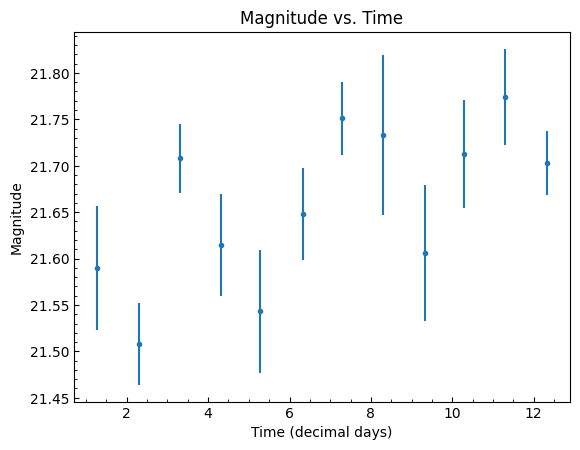

In [24]:
starmag = np.loadtxt('star_mags.dat')

time    = starmag[:,0] # in decimal days
mag     = starmag[:,1] # magnitude
mage    = starmag[:,2] # magnitude uncertainty

# Plot
plt.figure()
plt.errorbar(time, mag, yerr=mage, fmt='.')
plt.xlabel('Time (decimal days)')
plt.ylabel('Magnitude')
plt.title('Magnitude vs. Time')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.show()


- B) calculate the best-fitting average magnitude μ of the data. (Note that the data points don't have identical errors; see Bev Ch 4.)
    - Then calculate the $\chi^2$ you get from that $\mu$.
    - Then calculate the probability p that you'd expect such a value of $\chi^2$ by random chance. (use the [χ2cdf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html) cdf function.)
    


In [28]:
## Bevingtom most probably value LONG WAY

over  = []
under = []
for i in range(len(mag)):
    index_over = mag[i] / mage[i]**2
    index_under = 1 / mage[i]**2
    over.append(index_over)
    under.append(index_under)

mu1 = np.sum(over) / np.sum(under)

print(f'Best fit mu is : {mu1}')

Best fit mu is : 21.669934222747223


In [29]:
## SHORT WAY

mu = np.sum( mag / mage**2) / np.sum( 1 / mage**2)

print(mu)

21.669934222747223


In [30]:
chi2_mag = np.sum( (mag - mu)**2 / mage**2 )
print(f'The chi2 for mu is: {chi2_mag}')

The chi2 for mu is: 32.04312465303455


In [31]:
from scipy.stats import chi2

len(mag)

p = chi2.cdf(chi2_mag, 11)
print(f'THe p value is: {1-p}')

THe p value is: 0.0007506703331784381


In [ ]:
# 99.99999 chance we could get the same value by random chance so not a good value

- C) You should understand from the last part that assuming a constant brightness for the star is not a valid assumption. We propose a new hypothesis instead that the magnitude of the star changes linearly with time over the course of the observations. Thus the model for our hypothesis would be a line: $M = at + b$, where $a$ and $b$ are parameters to be fit. (Note that we're using capital M here for the model so that it's distinguishable from the lower-case m that was used above for the magnitudes. It's an unfortunate consequence of "model" and "magnitude" both starting with the letter m.) Let's first get an approximate sense about what $a$ and $b$ should be. 
    - 1) use polyfit to fit a line to the data and report its output for a and b. (you should find that a is around 0.015 and b is around 21.56.). Overplot the best fit model to the data


a (slope) = 0.01 mag / time
b (intercept) = 21.56 mag


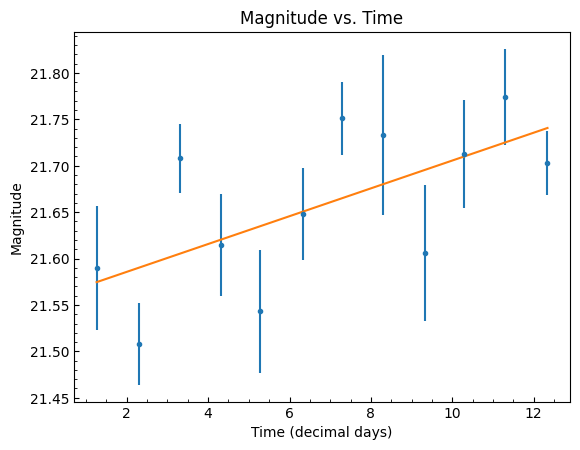

In [34]:
# Linear fit
a, b = np.polyfit(time, mag, deg=1)

print(f"a (slope) = {a:.2f} mag / time")
print(f"b (intercept) = {b:.2f} mag")

# Plot to verify
y = a * time + b

plt.figure()
plt.errorbar(time, mag, yerr=mage, fmt='.')
plt.plot(time, y, '-', label=f'Linear fit a = {a} mag / time')
plt.xlabel('Time (decimal days)')
plt.ylabel('Magnitude')
plt.title('Magnitude vs. Time')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.show()

### 
   - 2) polyfit does not account for the uncertainties in the data, so we should do a more careful job to find what $a$ and $b$ are and what their own uncertainties are. We will do this with the brute-force method, aka a "grid search". We set up a 1-D array of $na$ trial values for $a$, and another 1-D array of $nb$ trial values for $b$, and then create a 2-D array -- a grid of size na-by-nb -- of $\chi^2$ values. Each element of that array corresponds to one choice of a pair of values for $a$ and $b$. For example, the (17,37) element of the $\chi^2$ array holds the $\chi^2$ you get when you choose the 17th trial value from the $a$ array and the 37th trial value from the $b$ array to make the model $M = at + b$. <br><br> So let's first set up the 1-D arrays. Choose values for $na$ and $nb$, and also choose values for the minimum and maximum values of $a$ and b you want to search over. For example, $na \in [0.01, 0.03]$ and $nb \in [20, 22]$. Then, make the 1-D arrays that will hold all the trial values of $a$ and $b$. You don't need to print out any output for this problem, just be sure that it's clear that your code does these things. <br><br>(Hints: The advantage of using a relatively big range of values for a parameter is that you can search a greater area of parameter space. The disadvantage is that you may wind up searching an area that you already know is too far to have any hope of being the best answer, so it's a waste of computation time. The advantage of using a large value of $na$ and $nb$ would be that you can sample parameter space with a finer grid. The disadvantage is that it will take your computer longer to actually run the search. So while it may be tempting to use a finely-sampled large range, this is not a perfect solution. Going with too small a range and/or too coarse a grid, however, can be problematic as well since you might miss the best answer. For example, we know the right answer for a is going to be near 0.015, from Problem 3. So searching -0.005, +0.005, +0.015, +0.025, and +0.035 is likely to be too coarse. But searching ...., 0.0149998, 0.0149999, 0.0150000, 0.0150001, 0.0150002,... is probably too fine. The good thing is, if you get to the later problems and realize that you don't have a good grid here, you can change it.)
    


In [ ]:
na = np.arange(0.01, 0.03, 0.002)
nb = np.arange(20, 22, 0.01)

from itertools import product

chi_manfit = np.zeros( (len(na), len(nb)) )

for i in range(len(na)):
    for j in range(len(nb)):
        model = na[i] * time + nb[j]
        chi_manfit[i, j] = np.sum( ( mag - model)**2 / mage**2 )

In [47]:
best_model = np.where(chi_manfit == np.min( chi_manfit ))
print(f'Best fit is a =  {na[best_model[0][0]]}, b = {nb[best_model[1][0]]}' )
print(f'Best chi is = {np.min(chi_manfit)})')

Best fit is a =  0.012, b = 21.59000000000025
Best chi is = 21.354692371599132)


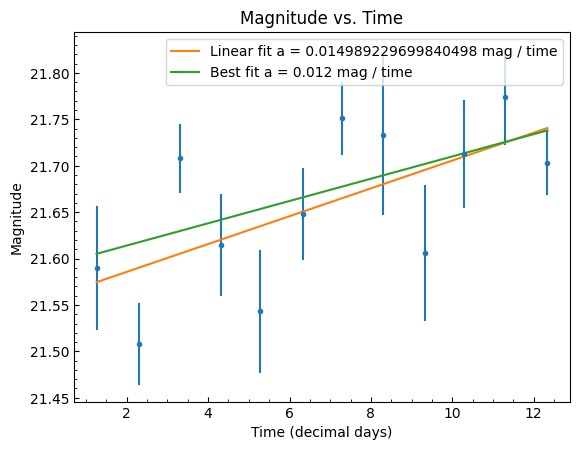

In [49]:
plt.figure()
plt.errorbar(time, mag, yerr=mage, fmt='.')
plt.plot(time, y, '-', label=f'Linear fit a = {a} mag / time')
plt.plot(time, na[best_model[0][0]] * time + nb[best_model[1][0]], '-', label=f'Best fit a = {na[best_model[0][0]]} mag / time')
plt.xlabel('Time (decimal days)')
plt.ylabel('Magnitude')
plt.title('Magnitude vs. Time')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.legend()
plt.show()

   - 3) Calculate your 2-D na-by-nb $\chi^2$ array. What is the minimum value of $\chi^2$, and at what location in parameter space does it occur? In other words, what values of $a$ and $b$ yield that minimum $\chi^2$? These will be considered the best-fitting values of the two parameters. Overplot the new best-fit model on the previous plot.
    


- 4) What is the probability that you'd get that high a value of $\chi^2$ by random chance (assuming as usual that the model is an appropriate description of the data)? Is this probability acceptable? 
    

- D)Make a contour plot of $\chi^2$, with the slopes $a$ on the x-axis and the intercepts $b$ on the y-axis. The contour plot should have four contours, one for each of: $1\sigma, 2\sigma, 3\sigma$ and $4\sigma$ levels. Also plot the location of the best-fitting parameters (i.e., the minimum of $\chi^2$) on the plot. <br><br> The basic paper in astronomy that reveals how to calculate these confidence intervals is by [Avni (1976)](https://articles.adsabs.harvard.edu/pdf/1976ApJ...210..642A). I'm sure that scientists in other fields figured this all out earlier; for some reason it was a confusing issue in astronomy (apparently) into the 1970s, even though the math behind all of this is far, far older. But anyway, the important part of that paper is his Table 1. For 68%, 90%, and 99% confidence intervals, and for models with 1, 2, or 3 parameters, the table gives the offsets that you need. In other words the numbers in that table are the uncertainties in $\chi^2$, $\Delta\chi^2$. So the procedure is this: (1) Decide what percentage confidence interval you want to quote (the $
\sigma$ for your contour plot). (2) Calculate the $\Delta\chi^2$ from that, given the number of parameters in your model. (3) Add that $\Delta\chi^2$ to your minimum $\chi^2$ (call it $\chi^2_\mathrm{min}$). (4) Find the parameter values that correspond to this level of $\chi^2_\mathrm{min}+\Delta\chi^2$. (5) That range is your confidence interval for that parameter. <br><br> If you want some tips on how to make the plot you can check [this out](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_label_demo.html)

In [61]:
#print(chi_manfit[9,:]) # SO its 9 columns long by presumably the 200
print(chi_manfit[:,1][0])

12514.315427721662


Text(0, 0.5, 'b')

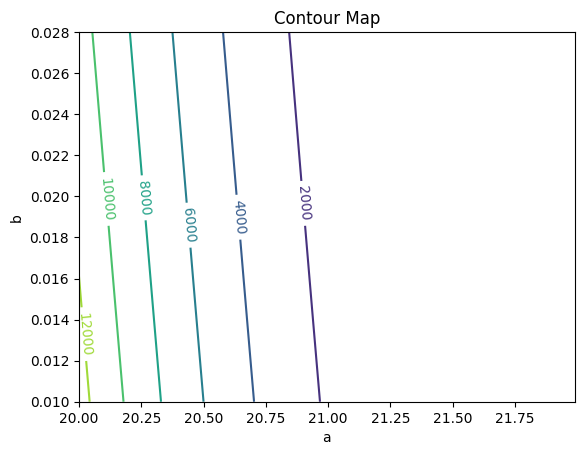

In [82]:
x = np.arange(0.01, 0.03, 0.002)
y = np.arange(20, 22, 0.01)

fig, ax = plt.subplots()
CS = ax.contour( y, x, chi_manfit)

ax.clabel( CS, inline = True )
ax.set_title('Contour Map')

ax.set_xlabel( 'a')
ax.set_ylabel( 'b')


ValueError: x and y must have same first dimension, but have shapes (10,) and (200,)

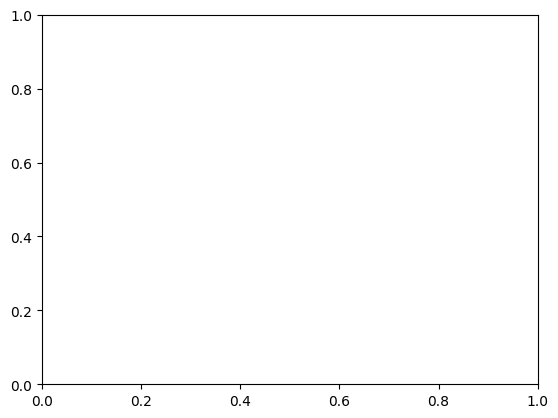

In [50]:
plt.figure()
plt.plot(na, nb)
plt.xlabel('a')
plt.ylabel('b')
plt.title('b vs. a')
plt.minorticks_on()
plt.tick_params(direction='in', which='both')
plt.legend()
plt.show()